<a href="https://colab.research.google.com/github/Martin-1431/Seth_INFO4670_Fall2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx

# Kept giving me deprecation warnings. Removed for clearer output.
import warnings
warnings.filterwarnings("ignore")

try:
    from google.colab import files
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    print("Running in Google Colab. Please upload bread_basket.csv")
    uploaded = files.upload()
    df = pd.read_csv('bread_basket.csv')
else:
    df = pd.read_csv('bread_basket.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Running in Google Colab. Please upload bread_basket.csv


Saving bread_basket.csv to bread_basket (2).csv
Dataset loaded successfully!
Shape: (20507, 6)


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [6]:
print("Variables and Data Types:")
print(df.dtypes)
print("\nDataFrame Info:")
df.info()

Variables and Data Types:
transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [8]:
print("Statistics Overview (include='all'):")
df.describe(include='all')

Statistics Overview (include='all'):


,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

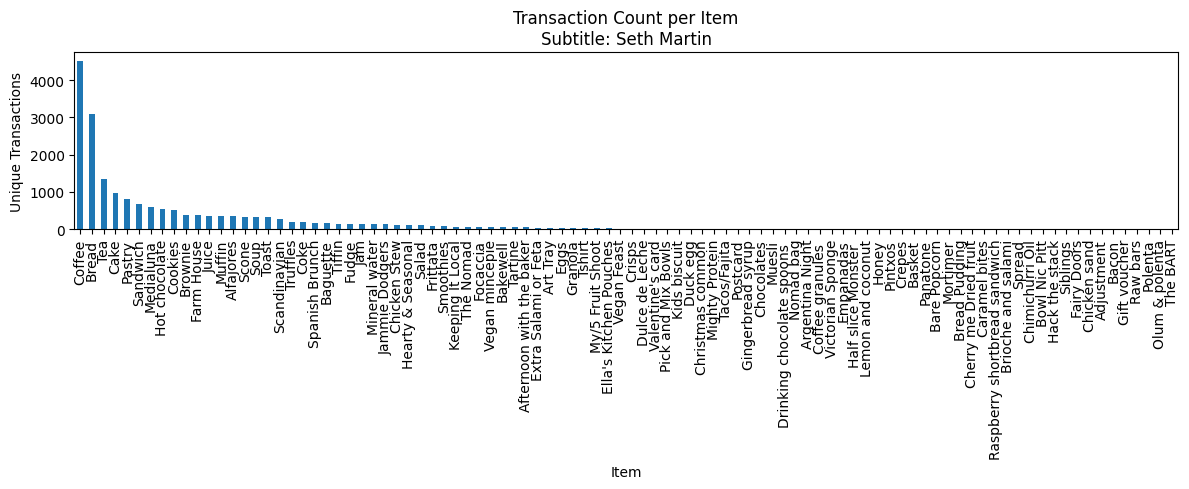

In [9]:
subtitle = "Seth Martin"
item_counts = df.groupby('item')['transaction'].nunique().sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [10]:
items_of_interest = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']

print("Item Transaction Counts:")
for item in items_of_interest:
    count = df[df['item'] == item]['transaction'].nunique()
    print(f"{item}: {count}")

print("\nTop 10 items by transaction count:")
print(item_counts.head(10))

Item Transaction Counts:
Coffee: 4528
Tea: 1350
Alfajores: 344
Juice: 365
Chicken Stew: 123

Top 10 items by transaction count:
item
Coffee           4528
Bread            3097
Tea              1350
Cake              983
Pastry            815
Sandwich          680
Medialuna         585
Hot chocolate     552
Cookies           515
Brownie           379
Name: transaction, dtype: int64


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [11]:
transaction_item_matrix = df.pivot_table(
    index='transaction',
    columns='item',
    aggfunc='size',
    fill_value=0
)

transaction_item_boolean = (transaction_item_matrix > 0).astype(int)

print(f"Transaction-Item Matrix Shape: {transaction_item_boolean.shape}")
print(f"Number of unique items: {transaction_item_boolean.shape[1]}")
print(f"Number of transactions: {transaction_item_boolean.shape[0]}")

min_support = 0.2
frequent_itemsets = fpgrowth(transaction_item_boolean,
                             min_support=min_support,
                             use_colnames=True)

print(f"\nFrequent itemsets (min_support={min_support}):")
print(f"Number of frequent itemsets: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Transaction-Item Matrix Shape: (9465, 94)
Number of unique items: 94
Number of transactions: 9465

Frequent itemsets (min_support=0.2):
Number of frequent itemsets: 2
    support  itemsets
1  0.478394  (Coffee)
0  0.327205   (Bread)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

Association Rules (confidence >= 0.01):
Number of rules: 74

Top 10 Rules by Lift:

Rule 1:
  {'Cake'} => {'Coffee', 'Tea'}
  Support: 0.0100, Confidence: 0.0966, Lift: 1.9380

Rule 2:
  {'Coffee', 'Tea'} => {'Cake'}
  Support: 0.0100, Confidence: 0.2013, Lift: 1.9380

Rule 3:
  {'Hot chocolate'} => {'Cake'}
  Support: 0.0114, Confidence: 0.1957, Lift: 1.8839

Rule 4:
  {'Cake'} => {'Hot chocolate'}
  Support: 0.0114, Confidence: 0.1099, Lift: 1.8839

Rule 5:
  {'Tea'} => {'Cake'}
  Support: 0.0238, Confidence: 0.1667, Lift: 1.6048

Rule 6:
  {'Cake'} => {'Tea'}
  Support: 0.0238, Confidence: 0.2289, Lift: 1.6048

Rule 7:
  {'Coffee'} => {'Toast'}
  Support: 0.0237, Confidence: 0.0495, Lift: 1.4724

Rule 8:
  {'Toast'} => {'Coffee'}
  Support: 0.0237, Confidence: 0.7044, Lift: 1.4724

Rule 9:
  {'Coffee', 'Bread'} => {'Pastry'}
  Support: 0.0112, Confidence: 0.1244, Lift: 1.4449

Rule 10:
  {'Pastry'} => {'Coffee', 'Bread'}
  Support: 0.0112, Confidence: 0.1301, Lift: 1.4449


Complete

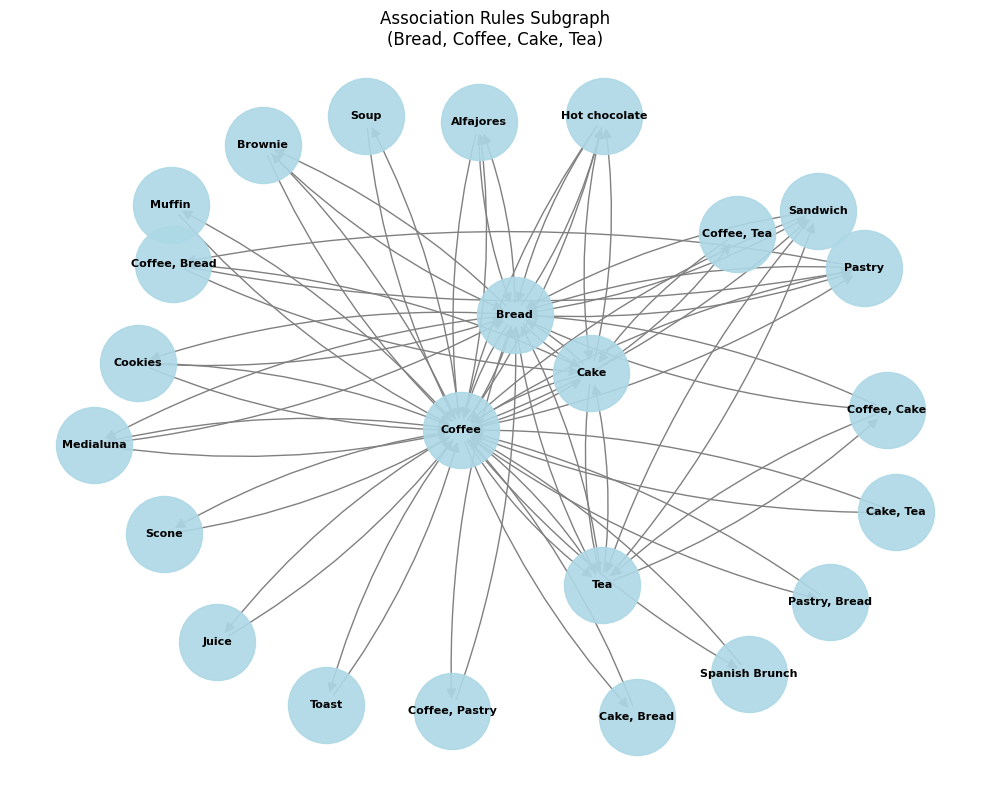

In [33]:
min_confidence = 0.01

itemsets_for_rules = fpgrowth(transaction_item_boolean,
                              min_support=0.01,
                              use_colnames=True)

rules = association_rules(itemsets_for_rules,
                         metric="confidence",
                         min_threshold=min_confidence)

if len(rules) > 0:
    print(f"Association Rules (confidence >= {min_confidence}):")
    print(f"Number of rules: {len(rules)}")

    rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    rules_display = rules_display.sort_values('lift', ascending=False)

    print("\nTop 10 Rules by Lift:")
    for idx, (i, row) in enumerate(rules_display.head(10).iterrows()):
        print(f"\nRule {idx+1}:")
        print(f"  {set(row['antecedents'])} => {set(row['consequents'])}")
        print(f"  Support: {row['support']:.4f}, Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.4f}")

    print("\n\nComplete Rules Report Table:")
    print(rules_display.to_string())

    target_items = {'Bread', 'Coffee', 'Cake', 'Tea'}
    subgraph_rules = []

    for idx, row in rules.iterrows():
        antecedent_set = set(row['antecedents'])
        consequent_set = set(row['consequents'])

        if (antecedent_set & target_items) or (consequent_set & target_items):
            subgraph_rules.append(row)

    if subgraph_rules:
        print(f"\n\nSubgraph for {target_items}:")
        print(f"Found {len(subgraph_rules)} rules involving these items")

        G = nx.DiGraph()

        for idx, row in enumerate(subgraph_rules):
            antecedent = ', '.join(list(row['antecedents']))
            consequent = ', '.join(list(row['consequents']))

            G.add_edge(antecedent, consequent,
                      confidence=row['confidence'],
                      lift=row['lift'])

        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, k=2, iterations=50)

        nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                              node_size=3000, alpha=0.9)
        nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
        nx.draw_networkx_edges(G, pos, edge_color='gray',
                              arrows=True, arrowsize=15,
                              connectionstyle='arc3,rad=0.1')

        plt.title(f"Association Rules Subgraph\n(Bread, Coffee, Cake, Tea)")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print(f"No rules found with confidence >= {min_confidence}. Try lowering the threshold.")

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

Interpretation (Plain English):
Customers who buy Coffee and Cake together sometimes also buy Bread, but this happens fairly rarely and not as often as you might expect.

Support:
The support value 0.010037 means that about 1.0% of all transactions contain Coffee, Cake, and Bread together.

Confidence:
The confidence value 0.183398 means that about 18.3% of customers who buy Coffee and Cake also buy Bread.

Lift (Practical Meaning):
The lift value 0.560497 is less than 1, which means there is a negative association between Bread and the combination of Coffee and Cake. In practical terms, customers who buy Coffee and Cake are less likely to buy Bread than the average customer, so this rule would not be useful for promotions or product placement.

>